# Austin Bayou SH 35: 2D breakout, NextGen conflation, boundary authoring, and validation

Reproduce a compact Austin Bayou “firehose” model at USGS 08078400. The example uses the public FEMA Austin–Oyster eBFE model and demonstrates four distinct tasks:

1. qualify a contained 2D breakout from the FEMA parent;
2. conflate the child domain against NextGen v2.2 flowpaths;
3. author the two domain-restricted boundaries in an isolated copy; and
4. validate the completed child against the parent model at the gauge.

The 4.6-square-mile child follows the connected 0.2% annual-chance floodplain plus 500 ft, cut about 0.5 mile upstream and 1 mile downstream of the gauge. It is a constant-flow diagnostic model—not a substitute for the watershed-preserving rain-on-mesh breakout. Tributaries inside the compact domain receive no inflow.

## Reproducibility and engineering boundary

`RasExamples` downloads the completed 30 MB child model. Set `RAS_COMMANDER_AUSTIN_OYSTER_PARENT` to the organized parent `Input` folder to run the parent preflight and direct parent/child WSE comparison. The public parent can be organized with `RasEbfeModels.organize_model("austin-oyster")`, but that delivery is approximately 24 GB and is intentionally not downloaded automatically here.

The committed notebook is an engineering demonstration. Always review the geometry, boundary placement, HEC-RAS computation messages, continuity, hydrographs, and spatial results manually before using a breakout for analysis.

In [1]:
from __future__ import annotations

import os
import shutil
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import Markdown, display
from shapely.geometry import LineString
from shapely.ops import substring

REPO_ROOT = Path.cwd() if (Path.cwd() / "examples").is_dir() else Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))

from ras_commander import (
    Breakout2DSpec,
    GeomBcLines,
    HdfBndry,
    HdfMesh,
    HdfResultsMesh,
    RasBreakout2D,
    RasExamples,
    RasNetworkConflation,
    RasPrj,
    RasUnsteady,
    init_ras_project,
)

WORKING_DIR = REPO_ROOT / "working" / "example_959_austin_bayou"
WORKING_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 12})
pd.set_option("display.max_colwidth", 100)

GAUGE_ID = "08078400"
PARENT_VALUE = os.getenv("RAS_COMMANDER_AUSTIN_OYSTER_PARENT", "").strip()
PARENT_PROJECT = Path(PARENT_VALUE) if PARENT_VALUE else None

## Load the completed RasExamples child

In [2]:
override = os.getenv("RAS_COMMANDER_SH35_FIREHOSE_PROJECT", "").strip()
if override:
    CHILD_PROJECT = Path(override)
else:
    extracted = RasExamples.extract_project(
        "AustinBayouSH35Firehose",
        output_path=WORKING_DIR,
        suffix="959",
    )
    CHILD_PROJECT = (
        extracted / "AustinBayou_SH35_Firehose" / "RAS Model" / "Input"
    )

assert (CHILD_PROJECT / "AustinOyster.prj").is_file(), CHILD_PROJECT
child_ras = RasPrj()
init_ras_project(
    CHILD_PROJECT,
    "6.6",
    ras_object=child_ras,
    load_results_summary=False,
    hide_intro=True,
)

child_geometry_hdf = CHILD_PROJECT / "AustinOyster.g01.hdf"
child_plan_hdf = CHILD_PROJECT / "AustinOyster.p01.hdf"
child_unsteady = CHILD_PROJECT / "AustinOyster.u01"
child_mesh = HdfMesh.get_mesh_areas(child_geometry_hdf)
gauge = gpd.read_file(CHILD_PROJECT / "Features" / "USGS_08078400.shp").to_crs(
    child_mesh.crs
)
assert gauge.iloc[0]["site_no"] == GAUGE_ID

NEXTGEN_URL = (
    "https://ciroh-community-ngen-datastream.s3.amazonaws.com/"
    "resources/v2.2_hydrofabric/geopackages/VPU_12/nextgen_VPU_12.gpkg"
)
NEXTGEN_BYTES = 200_265_728
nextgen_path = Path(os.getenv(
    "RAS_COMMANDER_NEXTGEN_VPU12",
    WORKING_DIR / "nextgen_VPU_12_v2.2.gpkg",
))
if not nextgen_path.exists() or nextgen_path.stat().st_size != NEXTGEN_BYTES:
    partial = nextgen_path.with_suffix(".gpkg.part")
    with requests.get(NEXTGEN_URL, stream=True, timeout=120) as response:
        response.raise_for_status()
        with partial.open("wb") as stream:
            for chunk in response.iter_content(1024 * 1024):
                if chunk:
                    stream.write(chunk)
    if partial.stat().st_size != NEXTGEN_BYTES:
        raise OSError("Unexpected NextGen VPU 12 download size")
    partial.replace(nextgen_path)

query_bounds = child_mesh.to_crs(5070).buffer(5000).total_bounds
flowpaths = gpd.read_file(nextgen_path, layer="flowpaths", bbox=tuple(query_bounds))
divides = gpd.read_file(nextgen_path, layer="divides", bbox=tuple(query_bounds))
coverage = RasNetworkConflation.classify_edges(
    child_mesh.assign(geometry_id="AustinBayou-SH35"),
    flowpaths,
    adapter="nextgen",
    geometry_id_col="geometry_id",
    analysis_crs=child_mesh.crs,
    include_outside=False,
)

child_summary = pd.DataFrame(
    [{
        "plan": "p01 — SH35_FIREHOSE",
        "mesh": child_mesh.iloc[0]["mesh_name"],
        "domain_sq_mi": child_mesh.geometry.iloc[0].area / 5280**2,
        "cells": int(child_ras.plan_df.loc[0, "mesh_cell_count"]),
        "forcing": "inline constant-flow ramp; no precipitation",
        "result_hdf": child_plan_hdf.name,
    }]
)
display(child_summary.style.format({"domain_sq_mi": "{:.2f}"}))

,plan,mesh,domain_sq_mi,cells,forcing,result_hdf
0,p01 — SH35_FIREHOSE,Perimeter 1,4.58,3311,inline constant-flow ramp; no precipitation,AustinOyster.p01.hdf


## Inspect the completed mesh and result

The child uses FEMA’s retained cell centers and refinement. The maximum-depth result provides immediate visual confirmation that the downloaded example is a computed hydraulic model rather than a geometry-only fixture.

2026-09-26 13:28:09 - ras_commander.hdf.HdfResultsMesh - INFO - Maximum-depth source for mesh 'Perimeter 1' in 'AustinOyster.p01.hdf': derived in memory by ras-commander from HEC-RAS HDF 'Water Surface' minus 'Cells Minimum Elevation'; no 'Depth' dataset was created or written.


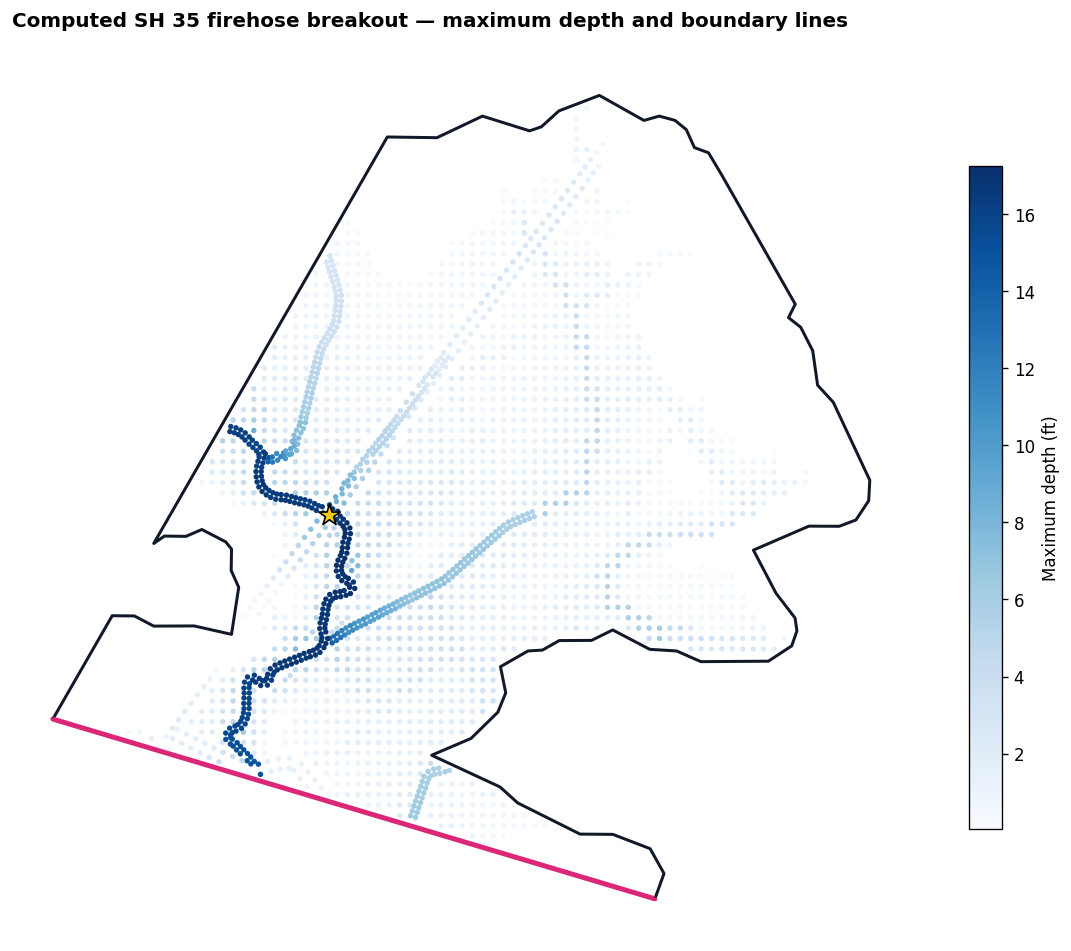

In [3]:
max_depth = HdfResultsMesh.get_mesh_max_depth(child_plan_hdf)
bc_lines = HdfBndry.get_bc_lines(child_geometry_hdf)

fig, ax = plt.subplots(figsize=(10, 8))
wet = max_depth.loc[max_depth["maximum_depth"] > 0.05]
wet.plot(
    ax=ax,
    column="maximum_depth",
    cmap="Blues",
    markersize=5,
    legend=True,
    legend_kwds={"label": "Maximum depth (ft)", "shrink": 0.75},
)
child_mesh.boundary.plot(ax=ax, color="#111827", linewidth=1.8, label="child perimeter")
bc_lines.loc[bc_lines["Type"] == "External"].plot(
    ax=ax,
    color="#db2777",
    linewidth=3.0,
)
gauge.plot(ax=ax, color="#facc15", edgecolor="black", marker="*", markersize=180, zorder=5)
ax.set_title("Computed SH 35 firehose breakout — maximum depth and boundary lines", loc="left", weight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Verify HEC-RAS native boundary-face ownership

`HdfBndry.get_bc_external_faces()` reads HEC-RAS’s own `External Faces` table. It is the authoritative check for which perimeter faces a BC line owns; geometric proximity to a drawn line is not sufficient. The completed source run has native ownership only for its downstream outlet. The recommended reach-level revision below replaces the source run’s interior inflow location with a wide upstream perimeter boundary.

2026-09-26 13:28:10 - ras_commander.hdf.HdfBndry - WARNING - Using native External Faces endpoints for 51 of 57 BC faces in mesh 'Perimeter 1' because their face IDs do not match current mesh topology in AustinOyster.g01.hdf.


,mesh_name,bc_line_name,face_count,first_face,last_face
0,Perimeter 1,Outlet_DS,57,6242,7312


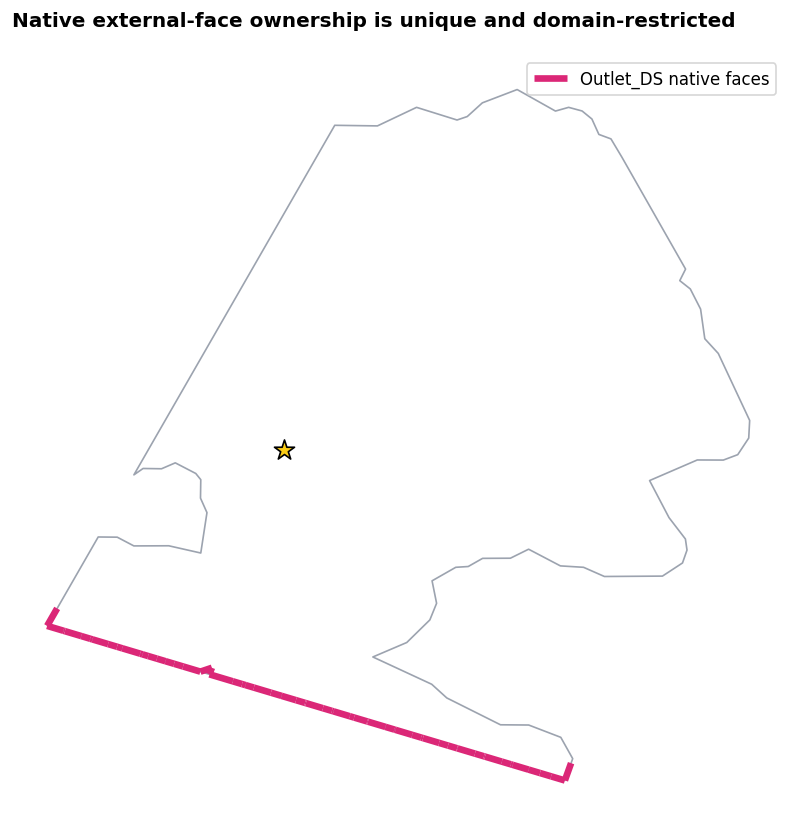

In [4]:
owned_faces = HdfBndry.get_bc_external_faces(
    child_geometry_hdf,
    include_geometry=True,
    validate_unique_faces=True,
)
face_summary = (
    owned_faces.groupby(["mesh_name", "bc_line_name"], dropna=False)
    .agg(face_count=("face_id", "size"), first_face=("face_id", "min"), last_face=("face_id", "max"))
    .reset_index()
)
assert owned_faces["face_id"].is_unique
assert set(face_summary["bc_line_name"]) == {"Outlet_DS"}
display(face_summary)

fig, ax = plt.subplots(figsize=(9, 7))
child_mesh.boundary.plot(ax=ax, color="#9ca3af", linewidth=1.0)
owned_faces.plot(ax=ax, color="#db2777", linewidth=4.0, label="Outlet_DS native faces")
gauge.plot(ax=ax, color="#facc15", edgecolor="black", marker="*", markersize=160)
ax.legend(loc="best")
ax.set_title("Native external-face ownership is unique and domain-restricted", loc="left", weight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Build a wide upstream external boundary

For a reach-level breakout, inflow belongs on a wide external cut—not on an internal emitter. The highest-drainage-area NextGen edge identifies the principal channel. Its upstream intersection with the child perimeter anchors a 3,000-foot boundary arc, wide enough to cover the active floodplain at the cut while remaining on the exterior ring.

The original project remains unchanged. The following cells delete its interior inflow line from an isolated geometry copy, add the new perimeter line, and attach the inflow hydrograph to that external boundary.

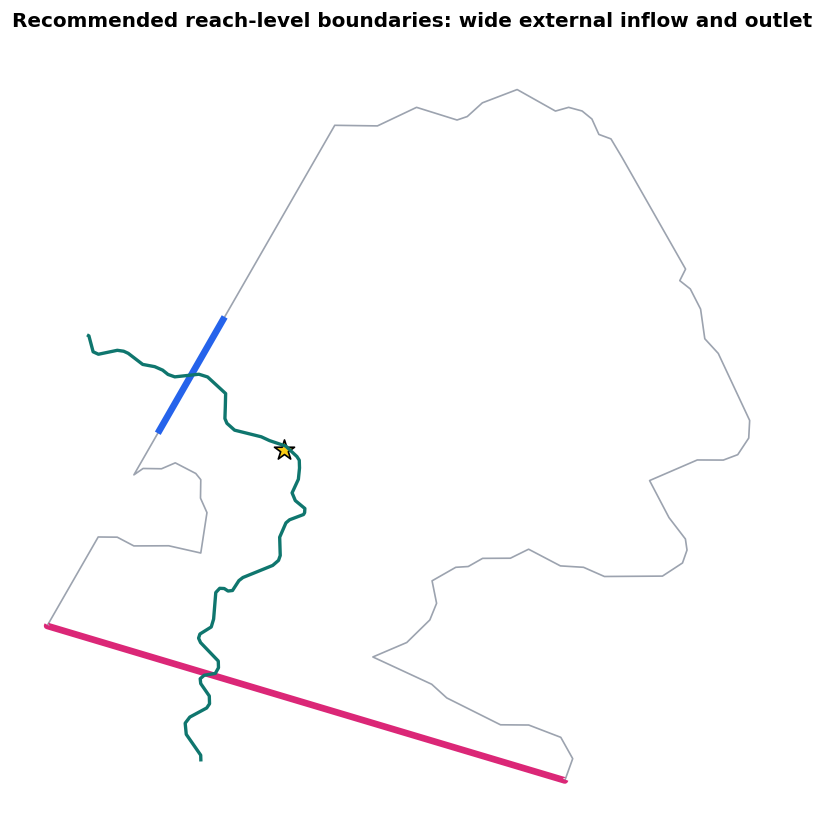

In [5]:
coverage_ranked = coverage.coverage_df.sort_values(
    ["drainage_area", "inside_fraction"], ascending=False
)
main_edge_id = str(coverage_ranked.iloc[0]["edge_id"])
flowpaths_model = flowpaths.to_crs(child_mesh.crs)
main_edge = flowpaths_model.loc[
    flowpaths_model["id"].astype(str) == main_edge_id
].geometry.iloc[0]
outlet_line = bc_lines.loc[bc_lines["Name"] == "Outlet_DS"].geometry.iloc[0]
crossings = main_edge.intersection(child_mesh.boundary.iloc[0])
crossing_points = list(crossings.geoms) if hasattr(crossings, "geoms") else [crossings]
upstream_crossing = max(crossing_points, key=lambda point: point.distance(outlet_line))

perimeter = LineString(child_mesh.geometry.iloc[0].exterior.coords)
upstream_station = perimeter.project(upstream_crossing)
half_width = 1500.0
assert half_width < upstream_station < perimeter.length - half_width
upstream_external = substring(
    perimeter,
    upstream_station - half_width,
    upstream_station + half_width,
)
assert upstream_external.distance(child_mesh.boundary.iloc[0]) < 1e-6

recommended_bc_lines = gpd.GeoDataFrame(
    {"bc_line": ["Inflow_US", "Outlet_DS"], "role": ["inflow", "outflow"]},
    geometry=[upstream_external, outlet_line],
    crs=child_mesh.crs,
)

fig, ax = plt.subplots(figsize=(9, 7))
child_mesh.boundary.plot(ax=ax, color="#9ca3af", linewidth=1.0)
recommended_bc_lines.plot(
    ax=ax,
    color=["#2563eb", "#db2777"],
    linewidth=4.0,
)
flowpaths_model.loc[flowpaths_model["id"].astype(str) == main_edge_id].plot(
    ax=ax, color="#0f766e", linewidth=2.0
)
gauge.plot(ax=ax, color="#facc15", edgecolor="black", marker="*", markersize=160)
ax.set_title("Recommended reach-level boundaries: wide external inflow and outlet", loc="left", weight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [6]:
authoring_dir = WORKING_DIR / "boundary_authoring"
authoring_dir.mkdir(parents=True, exist_ok=True)
geometry_copy = authoring_dir / "AustinOyster.g01"
unsteady_copy = authoring_dir / "AustinOyster.u01"
shutil.copy2(CHILD_PROJECT / "AustinOyster.g01", geometry_copy)
shutil.copy2(child_unsteady, unsteady_copy)

GeomBcLines.delete_bc_line(geometry_copy, "Emitter1")
GeomBcLines.add_bc_lines(
    geometry_copy,
    lines=[{
        "name": "Inflow_US",
        "storage_area": "Perimeter 1",
        "coordinates": list(upstream_external.coords),
    }],
)

reset = RasUnsteady.replace_2d_boundary_locations(
    unsteady_copy,
    geometry_copy,
    [
        {"area_2d": "Perimeter 1", "bc_line": "Inflow_US"},
        {"area_2d": "Perimeter 1", "bc_line": "Outlet_DS"},
    ],
)
hydrograph = pd.DataFrame(
    {
        "hour": np.arange(14, dtype=float),
        "value": [0, 1440, 2880, 4320, 5760, 7200, 8640, 8640, 8640, 8640, 8640, 8640, 8640, 8640],
    }
)
assert RasUnsteady.set_boundary_inline_hydrograph(
    unsteady_copy,
    hydrograph,
    bc_type="Flow Hydrograph",
    area_2d="Perimeter 1",
    bc_line="Inflow_US",
)
normal_depth = RasUnsteady.set_normal_depth_boundary(
    unsteady_copy,
    0.000362,
    area_2d="Perimeter 1",
    bc_line="Outlet_DS",
)
authored = RasUnsteady.extract_boundary_and_tables(
    unsteady_copy,
    ras_object=child_ras,
)
boundary_review = authored[["Storage Area Name", "Blank 1", "Tables"]].rename(
    columns={"Storage Area Name": "area_2d", "Blank 1": "bc_line"}
)
boundary_review["boundary_type"] = ["Flow Hydrograph", "Normal Depth"]
boundary_review["setting"] = ["peak = 8,640 cfs", "slope = 0.000362"]
display(boundary_review.drop(columns="Tables"))
assert set(boundary_review["bc_line"]) == {"Inflow_US", "Outlet_DS"}
assert len(boundary_review.iloc[0]["Tables"]["Flow Hydrograph"]) == 14
assert normal_depth["new_friction_slope"] == 0.000362

2026-09-26 13:28:10 - ras_commander.geom.GeomBcLines - INFO - Deleted BC line Emitter1 from AustinOyster.g01 (8 lines)


2026-09-26 13:28:10 - ras_commander.geom.GeomBcLines - INFO - Added 1 BC line(s) to AustinOyster.g01 (replaced=0)


2026-09-26 13:28:10 - ras_commander.RasUnsteady - INFO - Replaced 2 2D boundary block(s) with 2 geometry-backed location(s) in AustinOyster.u01


2026-09-26 13:28:10 - ras_commander.RasUnsteady - INFO - Updated Flow Hydrograph inline hydrograph in AustinOyster.u01: 14 values, interval=1HOUR, peak=8640.00


2026-09-26 13:28:10 - ras_commander.RasUnsteady - INFO - Set Normal Depth boundary in AustinOyster.u01: matched=,                ,        ,        ,                ,Perimeter 1     ,                ,Outlet_DS, slope=0.000362, flag=omitted, removed=0, inserted=1, updated_in_place=False


2026-09-26 13:28:10 - ras_commander.RasUnsteady - INFO - Successfully extracted boundaries and tables from C:\Users\bill\.config\superpowers\worktrees\ras-commander\pr388-austin-bayou\working\example_959_austin_bayou\boundary_authoring\AustinOyster.u01


,area_2d,bc_line,boundary_type,setting
0,Perimeter 1,Inflow_US,Flow Hydrograph,"peak = 8,640 cfs"
1,Perimeter 1,Outlet_DS,Normal Depth,slope = 0.000362


## Conflate the 2D domain to NextGen v2.2

A pure 2D model has no authoritative HEC-RAS river centerline or cross sections. For that case, `classify_edges()` is the correct extent-first conflation API: it reports every NextGen edge inside or crossing the child, without pretending there is a single exact reach match. The gauge remains an independent review point.

In [7]:
display(
    coverage.coverage_df[
        ["edge_id", "extent_status", "inside_fraction", "stream_order", "drainage_area"]
    ].sort_values(["extent_status", "inside_fraction"], ascending=[True, False])
)

,edge_id,extent_status,inside_fraction,stream_order,drainage_area
0,wb-2414043,partial,0.655512,2.0,113.377948
1,wb-2414058,partial,0.441944,1.0,11.585700
2,wb-2414059,partial,0.296596,1.0,4.982401
3,wb-2414057,partial,0.008324,1.0,9.015750


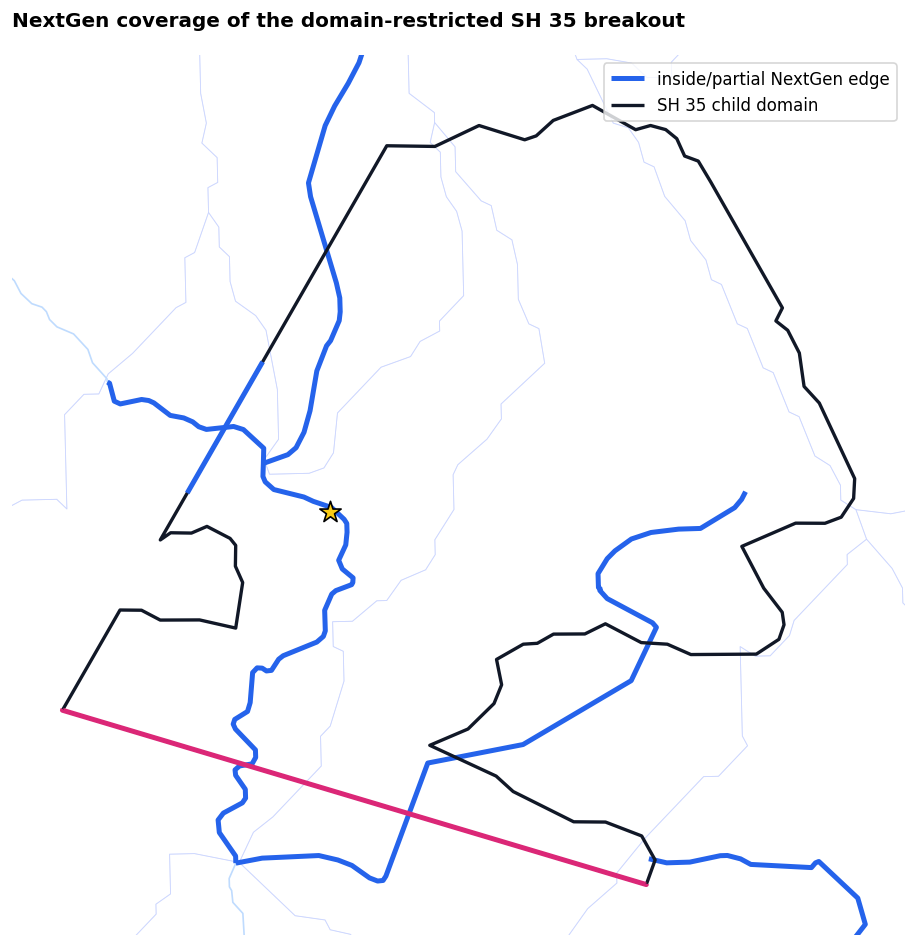

In [8]:
divides_model = divides.to_crs(child_mesh.crs)
accepted_ids = set(coverage.coverage_df["edge_id"].astype(str))
accepted = flowpaths_model.loc[flowpaths_model["id"].astype(str).isin(accepted_ids)]

fig, ax = plt.subplots(figsize=(10, 8))
divides_model.boundary.plot(ax=ax, color="#c7d2fe", linewidth=0.5, alpha=0.7)
flowpaths_model.plot(ax=ax, color="#bfdbfe", linewidth=1.0)
accepted.plot(ax=ax, color="#2563eb", linewidth=3.0, label="inside/partial NextGen edge")
child_mesh.boundary.plot(ax=ax, color="#111827", linewidth=2.0, label="SH 35 child domain")
recommended_bc_lines.plot(ax=ax, color=["#2563eb", "#db2777"], linewidth=3.0)
gauge.plot(ax=ax, color="#facc15", edgecolor="black", marker="*", markersize=180, zorder=6)
xmin, ymin, xmax, ymax = child_mesh.total_bounds
pad = 1000
ax.set(xlim=(xmin - pad, xmax + pad), ylim=(ymin - pad, ymax + pad), aspect="equal")
ax.legend(loc="best")
ax.set_title("NextGen coverage of the domain-restricted SH 35 breakout", loc="left", weight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Optional parent breakout preflight

When the organized parent is available, this cell proves that the exact child perimeter is contained, that the parent is a pure 2D unsteady plan, and that its unrelated 2D connection is safely classified for removal because it lies wholly outside the child. Connections touching the child—or connections with gates, culverts, or unverified extents—remain blocking.

In [9]:
parent_ras = None
preflight = None
if PARENT_PROJECT is None:
    display(Markdown(
        "Parent preflight skipped. Set `RAS_COMMANDER_AUSTIN_OYSTER_PARENT` "
        "to the organized Austin–Oyster `Input` folder to enable it."
    ))
else:
    parent_ras = RasPrj()
    init_ras_project(
        PARENT_PROJECT,
        "5.0.7",
        ras_object=parent_ras,
        load_results_summary=False,
        hide_intro=True,
    )
    preflight = RasBreakout2D.preflight(
        Breakout2DSpec(
            source_plan="08",
            source_2d_area="Perimeter 1",
            child_boundary=child_mesh,
            breakout_id="AustinBayou-SH35-firehose",
        ),
        ras_object=parent_ras,
    )
    assert preflight.is_ready, preflight.blocking_issues
    display(preflight.checks[["check_id", "passed", "blocking", "message"]])
    display(
        preflight.feature_actions.groupby(["feature_type", "action"])
        .size().rename("count").reset_index()
    )

2026-09-26 13:28:13 - ras_commander.RasPrj - WARNING - HEC-RAS 5.0.7 Terms & Conditions for Use have NOT been accepted for the current Windows user. The first headless/COM launch will block on a modal "Terms and Conditions for Use" dialog. Open HEC-RAS 5.0.7 in the GUI and click "I Agree" for that exact installed release. Terms: https://www.hec.usace.army.mil/software/hec-ras/


2026-09-26 13:28:22 - ras_commander.RasBreakout2D - INFO - 2D breakout preflight AustinBayou-SH35-firehose: ready=True, features=1533


,check_id,passed,blocking,message
0,pure_2d_plan,True,True,Source plan must be classified as valid unsteady pure 2D
1,single_2d_flow_area,True,True,Initial breakout preparation requires exactly one 2D flow area
2,unsupported_structures_absent,True,True,Child must exclude all structures; only verified external plain 2D connections may be dropped
3,child_within_parent,True,True,Child boundary must be contained by the parent 2D area
4,boundary_partition_closes,True,True,Inherited and artificial segments must close the child perimeter
5,reference_points_do_not_require_trim,True,True,Reference points requiring trim are outside the initial implementation


,feature_type,action,count
0,bc_line,preserve,60
1,breakline,clip,9
2,breakline,drop,1347
3,breakline,keep,4
4,mesh_area,replace,1
5,refinement_region,drop,44
6,sa_2d_connection,drop,1
7,unsteady_boundary,preserve,67


## Parent/child hydraulic validation at USGS 08078400

The completed constant-flow child is compared with the parent 1% rain-on-mesh result at the nearest mesh cell to the gauge. This is a focused reproduction check, not a complete validation. The full review also includes hydrograph shape, volume continuity, spatial WSE differences, sensitivity to the downstream slope, computation messages, and manual inspection in RAS Mapper.

In [10]:
child_ws = HdfResultsMesh.get_mesh_max_ws(child_plan_hdf)
child_gauge = gauge.to_crs(child_ws.crs).geometry.iloc[0]
child_index = child_ws.geometry.distance(child_gauge).idxmin()
child_row = child_ws.loc[child_index]

validation = {
    "USGS site": GAUGE_ID,
    "child maximum WSE (ft)": float(child_row["maximum_water_surface"]),
    "child cell offset (ft)": float(child_row.geometry.distance(child_gauge)),
    "parent maximum WSE (ft)": np.nan,
    "child minus parent (ft)": np.nan,
}
if parent_ras is not None:
    parent_plan_hdf = PARENT_PROJECT / "AustinOyster.p08.hdf"
    parent_ws = HdfResultsMesh.get_mesh_max_ws(parent_plan_hdf)
    parent_gauge = gauge.to_crs(parent_ws.crs).geometry.iloc[0]
    parent_index = parent_ws.geometry.distance(parent_gauge).idxmin()
    parent_row = parent_ws.loc[parent_index]
    validation["parent maximum WSE (ft)"] = float(parent_row["maximum_water_surface"])
    validation["child minus parent (ft)"] = (
        validation["child maximum WSE (ft)"] - validation["parent maximum WSE (ft)"]
    )
    assert abs(validation["child minus parent (ft)"]) <= 0.15

display(pd.DataFrame([validation]).style.format(precision=3))

,USGS site,child maximum WSE (ft),child cell offset (ft),parent maximum WSE (ft),child minus parent (ft)
0,08078400,26.637,41.039,26.699,-0.063


## Review checklist

- Confirm the small firehose domain is appropriate for the question; it does not retain upstream rain-on-mesh runoff.
- Review every clipped breakline and verify the dropped connection truly lies outside the child.
- Confirm `Inflow_US` and `Outlet_DS` attach to the intended perimeter faces after geometry preprocessing; reject any reach-level inflow that remains internal.
- Inspect solver messages and continuity; the original check run reported 0.013% continuity error.
- Review WSE and velocity spatially, not only at the gauge.
- Repeat the downstream-slope sensitivity when the domain, terrain, mesh, or design flow changes.
- Open the resulting project in RAS Mapper for manual diagnostics. A programmatic pass is evidence, not a substitute for engineering review.